# Sentiment analysis

i don't know if this will be in the final analysis but here it is

In [1]:
import pandas as pd
df = pd.read_parquet("./data/out/videos.parquet")
print(df.columns.tolist())

['id', 'etag', 'kind', 'channel_id', 'title', 'description', 'published_at', 'category_id', 'default_language', 'default_audio_language', 'duration', 'duration_seconds', 'definition', 'dimension', 'caption', 'licensed_content', 'projection', 'live_broadcast_content', 'view_count', 'like_count', 'comment_count', 'favorite_count', 'upload_status', 'privacy_status', 'license', 'embeddable', 'public_stats_viewable', 'made_for_kids', 'thumbnail_default_url', 'thumbnail_default_width', 'thumbnail_default_height', 'thumbnail_medium_url', 'thumbnail_medium_width', 'thumbnail_medium_height', 'thumbnail_high_url', 'thumbnail_high_width', 'thumbnail_high_height', 'thumbnail_standard_url', 'thumbnail_standard_width', 'thumbnail_standard_height', 'thumbnail_maxres_url', 'thumbnail_maxres_width', 'thumbnail_maxres_height', 'whisper_transcript_raw', 'whisper_transcript_text', 'word_count', 'tags', 'created_at', 'updated_at', 'channel_title', 'bert_output', 'sentiment', 'sentiment_confidence', 'sentim

In [2]:
df['sentiment'].value_counts()
df[['sentiment_positive_prob', 'sentiment_negative_prob', 'sentiment_neutral_prob', 'sentiment_confidence']].describe()

,sentiment_positive_prob,sentiment_negative_prob,sentiment_neutral_prob,sentiment_confidence
count,1001.000000,1001.000000,1001.000000,1001.000000
mean,0.057340,0.509751,0.432909,0.916016
std,0.176396,0.439910,0.440982,0.120801
min,0.000004,0.000004,0.000020,0.391324
25%,0.004249,0.028542,0.010510,0.910517
50%,0.008866,0.571710,0.162454,0.966480
75%,0.021962,0.970740,0.960660,0.987134
max,0.997972,0.999430,0.999991,0.999991


In [3]:
df.groupby('sentiment')[['view_count', 'like_count', 'comment_count']].median()

,view_count,like_count,comment_count
sentiment,,,
negative,40213.0,4246.0,170.0
neutral,39169.5,4244.5,168.0
positive,30882.5,2922.0,156.0


In [4]:
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

# Prep
reg_df = df.copy()
reg_df['log_view_count']    = np.log1p(reg_df['view_count'])
reg_df['log_like_count']    = np.log1p(reg_df['like_count'])
reg_df['log_comment_count'] = np.log1p(reg_df['comment_count'])
reg_df['like_rate']         = reg_df['like_count'] / reg_df['view_count'].replace(0, np.nan)
reg_df['comment_rate']      = reg_df['comment_count'] / reg_df['view_count'].replace(0, np.nan)
reg_df['log_duration']      = np.log1p(reg_df['duration_seconds'])
reg_df['log_word_count']    = np.log1p(reg_df['word_count'])

# Note: we drop sentiment_neutral_prob to avoid perfect multicollinearity
# (the three probs sum to 1). Neutral is the implicit baseline.
PREDICTORS = (
    'sentiment_positive_prob + sentiment_negative_prob '
    '+ log_duration + log_word_count'
)

outcomes = {
    'log_view_count':    'log_view_count',
    'log_like_count':    'log_like_count',
    'log_comment_count': 'log_comment_count',
    'like_rate':         'like_rate',
    'comment_rate':      'comment_rate',
}

results = {}
for name, outcome in outcomes.items():
    model_df = reg_df[[outcome, 'sentiment_positive_prob', 'sentiment_negative_prob',
                        'log_duration', 'log_word_count']].dropna()
    model = smf.ols(f'{outcome} ~ {PREDICTORS}', data=model_df).fit(cov_type='HC3')
    results[name] = model
    print(f'\n{"="*60}')
    print(f'OUTCOME: {name}  |  N={model.nobs:.0f}  |  R²={model.rsquared:.3f}')
    print(f'{"="*60}')
    print(model.summary2().tables[1].round(4))


OUTCOME: log_view_count  |  N=1001  |  R²=0.032
                           Coef.  Std.Err.        z   P>|z|   [0.025   0.975]
Intercept                12.0634    0.2717  44.4052  0.0000  11.5310  12.5959
sentiment_positive_prob  -0.0876    0.1946  -0.4500  0.6527  -0.4691   0.2939
sentiment_negative_prob   0.0710    0.0869   0.8178  0.4135  -0.0992   0.2413
log_duration             -0.7242    0.1314  -5.5123  0.0000  -0.9818  -0.4667
log_word_count            0.3176    0.0931   3.4126  0.0006   0.1352   0.5000

OUTCOME: log_like_count  |  N=1001  |  R²=0.025
                          Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
Intercept                9.0544    0.2697  33.5718  0.0000  8.5258  9.5830
sentiment_positive_prob -0.2489    0.1789  -1.3911  0.1642 -0.5997  0.1018
sentiment_negative_prob  0.0236    0.0782   0.3014  0.7631 -0.1298  0.1769
log_duration            -0.5988    0.1383  -4.3299  0.0000 -0.8699 -0.3278
log_word_count           0.3459    0.0973   3.5539  0.0004 

In [5]:
rows = []
for name, model in results.items():
    for var in ['sentiment_positive_prob', 'sentiment_negative_prob']:
        rows.append({
            'outcome': name,
            'predictor': var,
            'coef': model.params[var],
            'p_value': model.pvalues[var],
            'ci_low': model.conf_int().loc[var, 0],
            'ci_high': model.conf_int().loc[var, 1],
        })

summary = pd.DataFrame(rows)
summary['sig'] = summary['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)
print(summary.round(4).to_string(index=False))

          outcome               predictor    coef  p_value  ci_low  ci_high sig
   log_view_count sentiment_positive_prob -0.0876   0.6527 -0.4691   0.2939    
   log_view_count sentiment_negative_prob  0.0710   0.4135 -0.0992   0.2413    
   log_like_count sentiment_positive_prob -0.2489   0.1642 -0.5997   0.1018    
   log_like_count sentiment_negative_prob  0.0236   0.7631 -0.1298   0.1769    
log_comment_count sentiment_positive_prob  0.0242   0.8960 -0.3392   0.3877    
log_comment_count sentiment_negative_prob  0.0865   0.2308 -0.0550   0.2280    
        like_rate sentiment_positive_prob -0.0148   0.0370 -0.0288  -0.0009   *
        like_rate sentiment_negative_prob -0.0042   0.1638 -0.0102   0.0017    
     comment_rate sentiment_positive_prob  0.0005   0.3285 -0.0005   0.0015    
     comment_rate sentiment_negative_prob  0.0000   0.9973 -0.0004   0.0004    


In [7]:
import numpy as np

df['log_view_count'] = np.log1p(df['view_count'])
df['log_duration']   = np.log1p(df['duration_seconds'])
df['log_word_count'] = np.log1p(df['word_count'])

In [8]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd

# ── Prep data ────────────────────────────────────────────────────────────────
cols = ['log_view_count', 'sentiment_positive_prob', 'sentiment_negative_prob',
        'log_duration', 'log_word_count', 'channel_title']

m = df[cols].dropna().copy()

# Standardize predictors — important for MCMC sampling efficiency
def standardize(s):
    return (s - s.mean()) / s.std()

m['pos_z']  = standardize(m['sentiment_positive_prob'])
m['neg_z']  = standardize(m['sentiment_negative_prob'])
m['dur_z']  = standardize(m['log_duration'])
m['word_z'] = standardize(m['log_word_count'])

y = m['log_view_count'].values

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, b_pos, b_neg, b_dur, b_word, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
b_pos  -0.016  0.039  -0.086    0.059      0.000    0.000    8248.0    6129.0   
b_neg   0.031  0.038  -0.042    0.101      0.000    0.000    8471.0    5881.0   
b_dur  -0.364  0.072  -0.497   -0.226      0.001    0.001    5248.0    5441.0   
b_word  0.227  0.072   0.085    0.357      0.001    0.001    5219.0    5394.0   
sigma   1.185  0.027   1.138    1.237      0.000    0.000    8792.0    5710.0   

        r_hat  
b_pos     1.0  
b_neg     1.0  
b_dur     1.0  
b_word    1.0  
sigma     1.0  


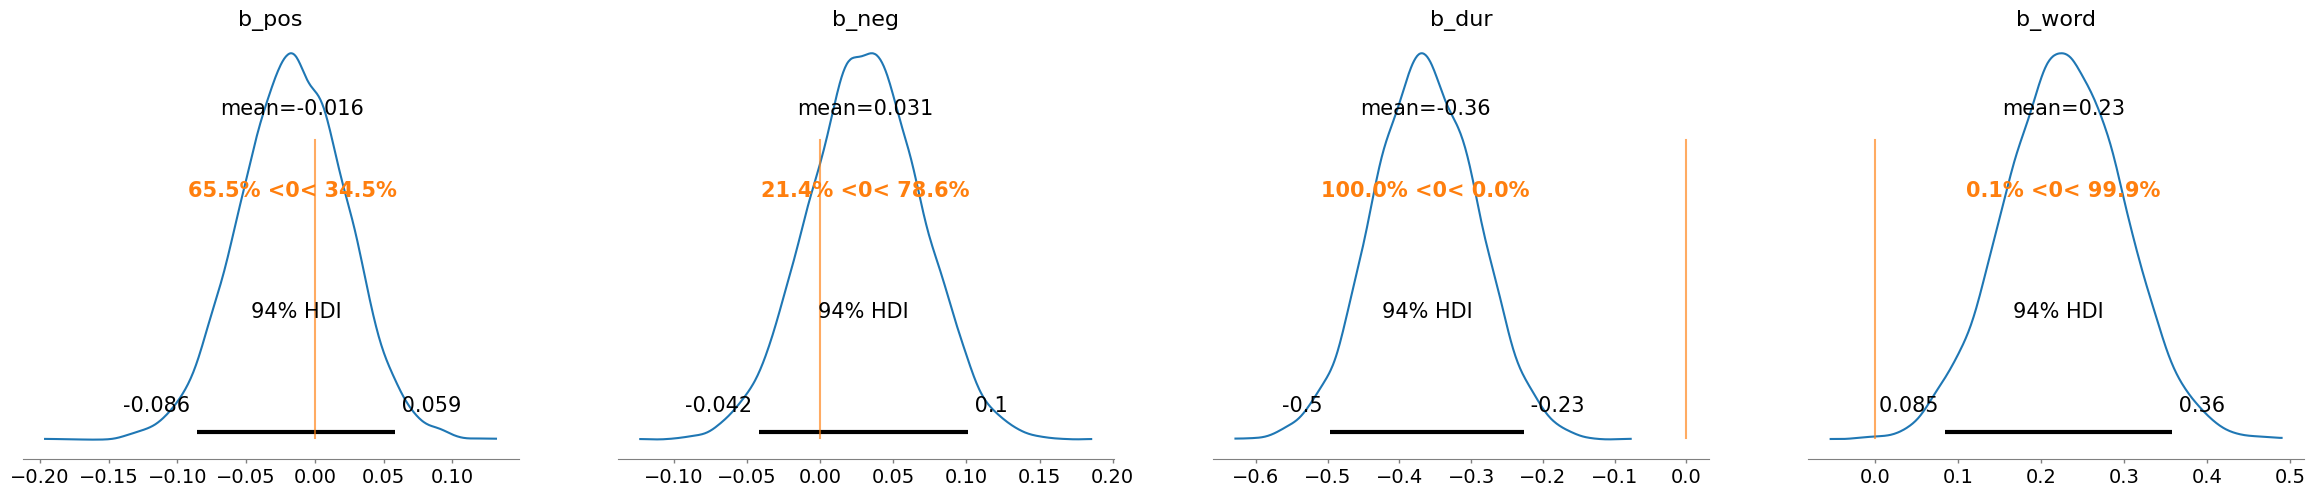

In [9]:
with pm.Model() as model_simple:
    # Weakly informative priors
    intercept = pm.Normal('intercept', mu=y.mean(), sigma=2)
    b_pos     = pm.Normal('b_pos',  mu=0, sigma=1)
    b_neg     = pm.Normal('b_neg',  mu=0, sigma=1)
    b_dur     = pm.Normal('b_dur',  mu=0, sigma=1)
    b_word    = pm.Normal('b_word', mu=0, sigma=1)
    sigma     = pm.HalfNormal('sigma', sigma=2)

    mu = (intercept
          + b_pos  * m['pos_z'].values
          + b_neg  * m['neg_z'].values
          + b_dur  * m['dur_z'].values
          + b_word * m['word_z'].values)

    likelihood = pm.Normal('y', mu=mu, sigma=sigma, observed=y)

    trace_simple = pm.sample(2000, tune=1000, target_accept=0.9,
                             return_inferencedata=True, random_seed=42)

az.plot_posterior(trace_simple,
                  var_names=['b_pos', 'b_neg', 'b_dur', 'b_word'],
                  ref_val=0)
print(az.summary(trace_simple, var_names=['b_pos','b_neg','b_dur','b_word','sigma']))

In [12]:
# Encode channels
channel_idx, channels = pd.factorize(m['channel_title'])
n_channels = len(channels)

with pm.Model() as model_hier:
    # Hyperpriors for channel intercepts
    mu_channel    = pm.Normal('mu_channel', mu=y.mean(), sigma=2)
    sigma_channel = pm.HalfNormal('sigma_channel', sigma=1)

    # Per-channel random intercepts (non-centered parameterization)
    z_channel   = pm.Normal('z_channel', mu=0, sigma=1, shape=n_channels)
    channel_int = pm.Deterministic('channel_int', mu_channel + z_channel * sigma_channel)

    # Fixed effects
    b_pos  = pm.Normal('b_pos',  mu=0, sigma=1)
    b_neg  = pm.Normal('b_neg',  mu=0, sigma=1)
    b_dur  = pm.Normal('b_dur',  mu=0, sigma=1)
    b_word = pm.Normal('b_word', mu=0, sigma=1)
    sigma  = pm.HalfNormal('sigma', sigma=2)

    mu = (channel_int[channel_idx]
          + b_pos  * m['pos_z'].values
          + b_neg  * m['neg_z'].values
          + b_dur  * m['dur_z'].values
          + b_word * m['word_z'].values)

    likelihood = pm.Normal('y', mu=mu, sigma=sigma, observed=y)

    trace_hier = pm.sample(2000, tune=1000, target_accept=0.95,
                           return_inferencedata=True, random_seed=42,
                           idata_kwargs={"log_likelihood": True})

az.plot_posterior(trace_hier,
                  var_names=['b_pos', 'b_neg', 'b_dur', 'b_word'],
                  ref_val=0)
print(az.summary(trace_hier, var_names=['b_pos','b_neg','b_dur','b_word',
                                         'mu_channel','sigma_channel','sigma']))

# ── Model comparison ────────────────────────────────────────────────────────
with model_simple:
    trace_simple = pm.sample(2000, tune=1000, target_accept=0.9,
                             return_inferencedata=True, random_seed=42,
                             idata_kwargs={"log_likelihood": True})

loo_simple = az.loo(trace_simple)
loo_hier   = az.loo(trace_hier)

print("Simple model LOO:", loo_simple)
print("Hierarchical LOO:", loo_hier)
print(az.compare({'simple': loo_simple, 'hierarchical': loo_hier}))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_channel, sigma_channel, z_channel, b_pos, b_neg, b_dur, b_word, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.
Initializing NUTS using jitter+adapt_diag...


                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
b_pos           0.035  0.032  -0.025    0.095      0.000    0.000    8097.0   
b_neg           0.048  0.033  -0.014    0.109      0.000    0.000    8673.0   
b_dur          -0.098  0.063  -0.218    0.016      0.001    0.001    5725.0   
b_word          0.134  0.061   0.016    0.242      0.001    0.001    5750.0   
mu_channel     10.816  0.494   9.853   11.735      0.009    0.008    2775.0   
sigma_channel   0.962  0.366   0.424    1.663      0.006    0.006    3472.0   
sigma           0.995  0.022   0.952    1.036      0.000    0.000    8254.0   

               ess_tail  r_hat  
b_pos            5574.0    1.0  
b_neg            5390.0    1.0  
b_dur            5093.0    1.0  
b_word           5055.0    1.0  
mu_channel       3556.0    1.0  
sigma_channel    4456.0    1.0  
sigma            5430.0    1.0  


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, b_pos, b_neg, b_dur, b_word, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Simple model LOO: Computed from 8000 posterior samples and 1001 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1593.35    23.31
p_loo        5.63        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1001  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

Hierarchical LOO: Computed from 8000 posterior samples and 1001 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1419.11    26.76
p_loo        8.70        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1001  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

              rank     elpd_loo     p_loo   elpd_diff        weight  \
hierarchical     0 -1419.107376  8.701536    0.000000  1.000000e+00   
simple           1 -1593.352352  5.632136  174.244976  4.082200e-10   

                     se       dse  warni